<a href="https://colab.research.google.com/github/ishwarya146/Personal-Habit-Tracker-with-Progress-Charts/blob/main/Personal_Habit_Tracker_with_Progress_Charts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Welcome to Personal Habit Tracker!
Track your daily habits and visualize your progress!

           PERSONAL HABIT TRACKER
1. Add New Habit
2. List All Habits
3. Mark Habit Complete (Today)
4. Mark Habit Incomplete (Today)
5. View Today's Progress
6. View Weekly Progress Chart
7. View Completion Rates Chart
8. Remove Habit
9. Save & Exit
--------------------------------------------------
Enter your choice (1-9): 1
Enter habit name: exercise
Enter habit description (optional): meditation habit
Added habit: 'exercise'
Data saved successfully!

           PERSONAL HABIT TRACKER
1. Add New Habit
2. List All Habits
3. Mark Habit Complete (Today)
4. Mark Habit Incomplete (Today)
5. View Today's Progress
6. View Weekly Progress Chart
7. View Completion Rates Chart
8. Remove Habit
9. Save & Exit
--------------------------------------------------
Enter your choice (1-9): 2

=== YOUR HABITS ===
1. ✓ exercise
   Description: meditation habit
   Created: 2026-01-28


           PERSONAL HABIT TRAC

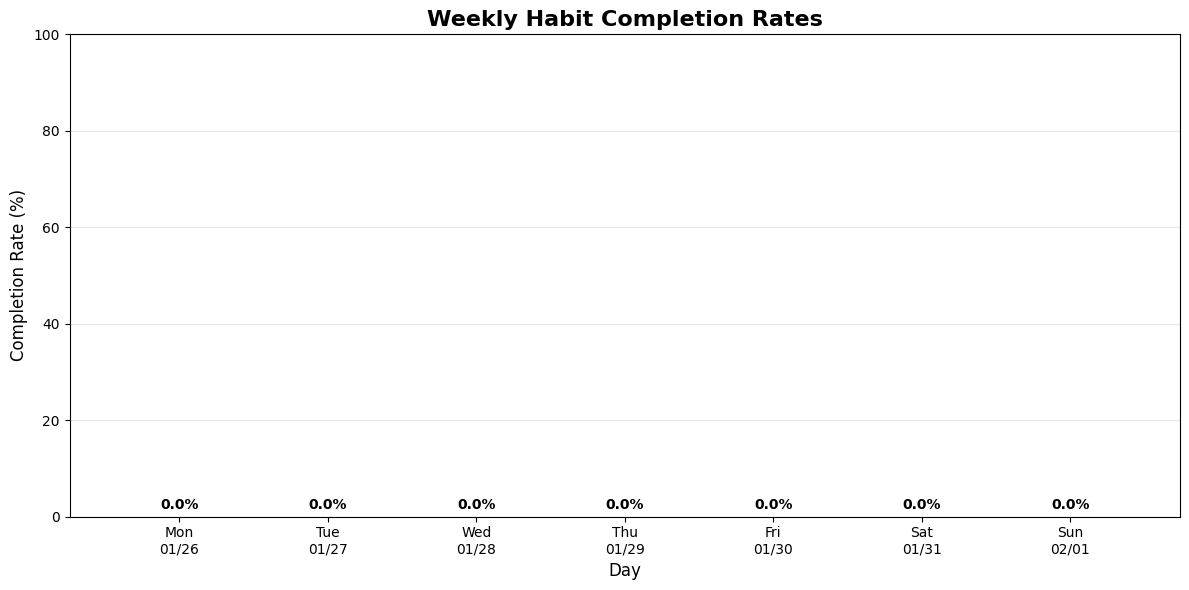


           PERSONAL HABIT TRACKER
1. Add New Habit
2. List All Habits
3. Mark Habit Complete (Today)
4. Mark Habit Incomplete (Today)
5. View Today's Progress
6. View Weekly Progress Chart
7. View Completion Rates Chart
8. Remove Habit
9. Save & Exit
--------------------------------------------------


In [ ]:
"""
Personal Habit Tracker with Progress Charts
Track daily habits, mark completion, and view progress with bar chart visualization
"""

import json
import os
import datetime
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

class HabitTracker:
    def __init__(self, data_file="habits_data.json"):
        self.data_file = data_file
        self.habits = {}
        self.completed_habits = defaultdict(lambda: defaultdict(bool))
        self.load_data()

    def load_data(self):
        """Load habit data from JSON file"""
        if os.path.exists(self.data_file):
            try:
                with open(self.data_file, 'r') as f:
                    data = json.load(f)
                    self.habits = data.get('habits', {})

                    # Convert string dates back to date objects for completed_habits
                    completed_data = data.get('completed_habits', {})
                    for habit_name, dates in completed_data.items():
                        for date_str, status in dates.items():
                            date_obj = datetime.datetime.strptime(date_str, '%Y-%m-%d').date()
                            self.completed_habits[habit_name][date_obj] = status

                print(f"Loaded data from {self.data_file}")
            except Exception as e:
                print(f"Error loading data: {e}")
                print("Starting with fresh data...")

    def save_data(self):
        """Save habit data to JSON file"""
        try:
            # Convert date objects to strings for JSON serialization
            completed_data = {}
            for habit_name, dates in self.completed_habits.items():
                completed_data[habit_name] = {}
                for date_obj, status in dates.items():
                    date_str = date_obj.strftime('%Y-%m-%d')
                    completed_data[habit_name][date_str] = status

            data = {
                'habits': self.habits,
                'completed_habits': completed_data
            }

            with open(self.data_file, 'w') as f:
                json.dump(data, f, indent=2)
            print("Data saved successfully!")
        except Exception as e:
            print(f"Error saving data: {e}")

    def add_habit(self, name, description=""):
        """Add a new habit to track"""
        if name in self.habits:
            print(f"Habit '{name}' already exists!")
            return False

        self.habits[name] = {
            'description': description,
            'created_date': datetime.date.today().strftime('%Y-%m-%d'),
            'active': True
        }
        print(f"Added habit: '{name}'")
        self.save_data()
        return True

    def remove_habit(self, name):
        """Remove a habit from tracking"""
        if name not in self.habits:
            print(f"Habit '{name}' not found!")
            return False

        confirm = input(f"Are you sure you want to remove '{name}'? (y/N): ").lower()
        if confirm == 'y':
            del self.habits[name]
            # Also remove completion data
            if name in self.completed_habits:
                del self.completed_habits[name]
            print(f"Removed habit: '{name}'")
            self.save_data()
            return True
        return False

    def list_habits(self):
        """Display all active habits"""
        if not self.habits:
            print("No habits added yet!")
            return

        print("\n=== YOUR HABITS ===")
        for i, (name, info) in enumerate(self.habits.items(), 1):
            status = "✓" if info.get('active', True) else "✗"
            created = info.get('created_date', 'Unknown')
            description = info.get('description', 'No description')
            print(f"{i}. {status} {name}")
            print(f"   Description: {description}")
            print(f"   Created: {created}")
            print()

    def mark_habit_complete(self, habit_name, date=None):
        """Mark a habit as completed for a specific date"""
        if habit_name not in self.habits:
            print(f"Habit '{habit_name}' not found!")
            return False

        if date is None:
            date = datetime.date.today()

        self.completed_habits[habit_name][date] = True
        print(f"Marked '{habit_name}' as completed for {date}")
        self.save_data()
        return True

    def mark_habit_incomplete(self, habit_name, date=None):
        """Mark a habit as incomplete for a specific date"""
        if habit_name not in self.habits:
            print(f"Habit '{habit_name}' not found!")
            return False

        if date is None:
            date = datetime.date.today()

        self.completed_habits[habit_name][date] = False
        print(f"Marked '{habit_name}' as incomplete for {date}")
        self.save_data()
        return True

    def get_habit_status_for_date(self, habit_name, date):
        """Get completion status for a habit on a specific date"""
        return self.completed_habits[habit_name].get(date, False)

    def get_weekly_data(self, start_date=None):
        """Get habit completion data for a week"""
        if start_date is None:
            # Start from last Monday
            today = datetime.date.today()
            days_since_monday = today.weekday()
            start_date = today - datetime.timedelta(days=days_since_monday)

        week_dates = [start_date + datetime.timedelta(days=i) for i in range(7)]
        weekly_data = {}

        for habit_name in self.habits.keys():
            weekly_data[habit_name] = []
            for date in week_dates:
                completed = self.get_habit_status_for_date(habit_name, date)
                weekly_data[habit_name].append(completed)

        return weekly_data, week_dates

    def calculate_completion_rates(self, days=7):
        """Calculate completion rates for each habit over specified days"""
        end_date = datetime.date.today()
        start_date = end_date - datetime.timedelta(days=days-1)

        rates = {}
        for habit_name in self.habits.keys():
            completed_count = 0
            total_days = 0

            current_date = start_date
            while current_date <= end_date:
                if self.get_habit_status_for_date(habit_name, current_date):
                    completed_count += 1
                total_days += 1
                current_date += datetime.timedelta(days=1)

            rates[habit_name] = (completed_count / total_days) * 100 if total_days > 0 else 0

        return rates

    def show_daily_progress(self, date=None):
        """Show progress for a specific day"""
        if date is None:
            date = datetime.date.today()

        print(f"\n=== PROGRESS FOR {date.strftime('%A, %B %d, %Y')} ===")

        if not self.habits:
            print("No habits to track!")
            return

        completed_count = 0
        total_habits = len(self.habits)

        for habit_name in self.habits.keys():
            status = "✓" if self.get_habit_status_for_date(habit_name, date) else "✗"
            if status == "✓":
                completed_count += 1
            print(f"{status} {habit_name}")

        completion_rate = (completed_count / total_habits) * 100 if total_habits > 0 else 0
        print(f"\nDaily Progress: {completed_count}/{total_habits} ({completion_rate:.1f}%)")

    def create_progress_chart(self, chart_type="weekly"):
        """Create and display progress charts"""
        if not self.habits:
            print("No habits to chart!")
            return

        plt.style.use('default')

        if chart_type == "weekly":
            self._create_weekly_chart()
        elif chart_type == "rates":
            self._create_completion_rates_chart()
        else:
            print("Invalid chart type!")

    def _create_weekly_chart(self):
        """Create a weekly progress bar chart"""
        weekly_data, week_dates = self.get_weekly_data()

        if not weekly_data:
            print("No data available for charting!")
            return

        # Calculate daily completion rates
        daily_rates = []
        day_labels = []

        for i, date in enumerate(week_dates):
            completed_today = sum(1 for habit_data in weekly_data.values() if habit_data[i])
            total_habits = len(weekly_data)
            rate = (completed_today / total_habits) * 100 if total_habits > 0 else 0
            daily_rates.append(rate)
            day_labels.append(date.strftime('%a\n%m/%d'))

        plt.figure(figsize=(12, 6))

        # Create bar chart
        bars = plt.bar(day_labels, daily_rates, color=['#2ecc71' if rate >= 80 else '#f39c12' if rate >= 50 else '#e74c3c' for rate in daily_rates])

        plt.title('Weekly Habit Completion Rates', fontsize=16, fontweight='bold')
        plt.xlabel('Day', fontsize=12)
        plt.ylabel('Completion Rate (%)', fontsize=12)
        plt.ylim(0, 100)

        # Add percentage labels on bars
        for bar, rate in zip(bars, daily_rates):
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

        # Add grid for better readability
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    def _create_completion_rates_chart(self):
        """Create a habit completion rates chart"""
        rates = self.calculate_completion_rates(days=7)

        if not rates:
            print("No data available for charting!")
            return

        habit_names = list(rates.keys())
        completion_rates = list(rates.values())

        plt.figure(figsize=(10, 6))

        # Create horizontal bar chart for better habit name visibility
        colors = ['#2ecc71' if rate >= 80 else '#f39c12' if rate >= 50 else '#e74c3c' for rate in completion_rates]
        bars = plt.barh(habit_names, completion_rates, color=colors)

        plt.title('7-Day Habit Completion Rates', fontsize=16, fontweight='bold')
        plt.xlabel('Completion Rate (%)', fontsize=12)
        plt.xlim(0, 100)

        # Add percentage labels
        for bar, rate in zip(bars, completion_rates):
            width = bar.get_width()
            plt.text(width + 1, bar.get_y() + bar.get_height()/2.,
                    f'{rate:.1f}%', ha='left', va='center', fontweight='bold')

        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

def display_menu():
    """Display the main menu"""
    print("\n" + "="*50)
    print("           PERSONAL HABIT TRACKER")
    print("="*50)
    print("1. Add New Habit")
    print("2. List All Habits")
    print("3. Mark Habit Complete (Today)")
    print("4. Mark Habit Incomplete (Today)")
    print("5. View Today's Progress")
    print("6. View Weekly Progress Chart")
    print("7. View Completion Rates Chart")
    print("8. Remove Habit")
    print("9. Save & Exit")
    print("-" * 50)

def get_habit_choice(tracker):
    """Helper function to let user choose a habit"""
    habits = list(tracker.habits.keys())
    if not habits:
        print("No habits available!")
        return None

    print("\nAvailable habits:")
    for i, habit in enumerate(habits, 1):
        print(f"{i}. {habit}")

    try:
        choice = int(input("Choose habit number: ")) - 1
        if 0 <= choice < len(habits):
            return habits[choice]
        else:
            print("Invalid choice!")
            return None
    except ValueError:
        print("Please enter a valid number!")
        return None



# Run the application
tracker = HabitTracker()

print("Welcome to Personal Habit Tracker!")
print("Track your daily habits and visualize your progress!")

while True:
    display_menu()

    try:
        choice = input("Enter your choice (1-9): ").strip()

        if choice == '1':
            name = input("Enter habit name: ").strip()
            if name:
                description = input("Enter habit description (optional): ").strip()
                tracker.add_habit(name, description)
            else:
                print("Habit name cannot be empty!")

        elif choice == '2':
            tracker.list_habits()

        elif choice == '3':
            habit = get_habit_choice(tracker)
            if habit:
                tracker.mark_habit_complete(habit)

        elif choice == '4':
            habit = get_habit_choice(tracker)
            if habit:
                tracker.mark_habit_incomplete(habit)

        elif choice == '5':
            tracker.show_daily_progress()

        elif choice == '6':
            print("Generating weekly progress chart...")
            tracker.create_progress_chart("weekly")

        elif choice == '7':
            print("Generating completion rates chart...")
            tracker.create_progress_chart("rates")

        elif choice == '8':
            habit = get_habit_choice(tracker)
            if habit:
                tracker.remove_habit(habit)

        elif choice == '9':
            tracker.save_data()
            print("Thank you for using Personal Habit Tracker!")
            print("Keep building those good habits! 💪")
            break

        else:
            print("Invalid choice! Please enter 1-9.")

    except KeyboardInterrupt:
        print("\n\nExiting...")
        tracker.save_data()
        break
    except Exception as e:
        print(f"An error occurred: {e}")